In [55]:
from math import pi

import numpy as np
import matplotlib.pyplot as plt
import tqdm
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.utils import load_arguments

In [2]:
def sinc(x):
    return np.sinc(x/np.pi)

def dsinc(x):
    return np.piecewise(
        x,
        [abs(x) > 0],
        [
            lambda x: (np.cos(x) - sinc(x))/x,
            0.0,
        ]
    )

def sinc_inv(y):
    x = np.pi*(1 - y)
    # 10 newton iterations should be enough.
    for _ in range(10):
        x = x - (sinc(x) - y)/(dsinc(x) + 1e-6)
    return x

def calculate_EJdivEB(ratio):
    a = sinc_inv(ratio)
    return 1/(1 - a * np.sin(a)/2 - np.cos(a))

In [3]:
parent_path = DATA_DIR/"fluxonium_quantization"/"dim=8_cutoff=128"
argm = load_arguments(parent_path)

In [12]:
ELdivEJ_coord = xr.DataArray(
    argm.ELdivEJ,
    dims=['ELdivEJ'],
)
EBdivEC_coord = xr.DataArray(
    argm.EBdivEC,
    dims=['EBdivEC'],
)
bra_coord = xr.DataArray(
    np.arange(argm.levels),
    dims=['bra'],
)
ket_coord = xr.DataArray(
    np.arange(argm.levels),
    dims=['ket'],
)

dataset = xr.Dataset()
dataset['eigenenergy'] = xr.DataArray(
    np.nan,
    coords=[ELdivEJ_coord, EBdivEC_coord, ket_coord]
)
dataset['charge'] = xr.DataArray(
    np.nan,
    coords=[ELdivEJ_coord, EBdivEC_coord, bra_coord, ket_coord]
)

In [13]:
for ELdivEJ in tqdm.tqdm(dataset.ELdivEJ.data):
    ds = dataset.loc[dict(ELdivEJ=ELdivEJ)]
    scale = calculate_EJdivEB(ELdivEJ)
    EJdivEC = ds.EBdivEC.data * scale
    fx = Fluxonium(
        EJ=EJdivEC,
        EC=1.0,
        EL=ELdivEJ * EJdivEC,
        dim=argm.levels,
        cutoff=argm.cutoff,
    )
    evals = fx.eigenvalues
    n_op = fx.get_operator('charge')
    ds['eigenenergy'][:] = evals
    ds['charge'][:] = abs(n_op)

100%|███████████████████████████████████████████████████| 51/51 [03:12<00:00,  3.78s/it]


In [14]:
dataset.to_netcdf(parent_path/"dataset.hdf5")

# Quick analysis

Checking what the min/max residual ZZ, $f_{30}$, $f_{21}$, etc. frequencies are in our sample space.

In [5]:
dataset = xr.load_dataset(parent_path/"dataset.hdf5")

In [137]:
import scipy.stats.qmc

_random_sampler = scipy.stats.qmc.Sobol(d=3, scramble=True)

def generate_random_parameters(num):
    # Over sample since we will mask some points later.
    u, v, w = _random_sampler.random(2**int(np.ceil(np.log2(num))+2)).T

    EC_array = (1.0 + 0.5*u) * 2*pi
    EL_array = (0.1 + 1.9*v) * 2*pi
    EJ_array = (2 + 8*w) * 2*pi
    
    ratio = EL_array/EJ_array
    
    mask = (ratio >= 0.1) & (ratio <= 0.5)
    
    EJ_array = EJ_array[mask][:num]
    EC_array = EC_array[mask][:num]
    EL_array = EL_array[mask][:num]
    
    return EJ_array, EC_array, EL_array

In [275]:
EJ_values, EC_values, EL_values = generate_random_parameters(2**10)

In [278]:
from fluxoniumcr.qubits.product_basis import ProductBasis, DressedProductBasis

evals = []
for (EJ, EC, EL) in tqdm.tqdm(zip(EJ_values, EC_values, EL_values)):
    q0 = Fluxonium(
        EJ=4 * 2*pi,
        EC=1.2 * 2*pi,
        EL=0.4 * 2*pi,
        dim=6,
        cutoff=64,
    )

    q1 = Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        dim=6,
        cutoff=64,
    )

    bare_basis = ProductBasis([q0, q1])
    H_q0 = bare_basis.get_operator({0: 'hamiltonian'})
    H_q1 = bare_basis.get_operator({1: 'hamiltonian'})
    n0n1 = bare_basis.get_operator(['charge', 'charge'])
    J = 100e-3 * 2*pi

    dressed_basis = DressedProductBasis(
        H_q0 + H_q1 + J*n0n1,
        bare_basis,
        truncated_dims=(2, 2),
    )
    evals.append(dressed_basis.eigenvalues)
evals = np.array(evals)

1024it [00:15, 66.35it/s]


In [294]:
residual_zz = abs(evals[:, 3] + evals[:, 0] - (evals[:, 1] + evals[:, 2]))

np.quantile(residual_zz, [0.03, 0.93]) * 1e6/(2*pi)

array([12.22991218, 99.54947421])

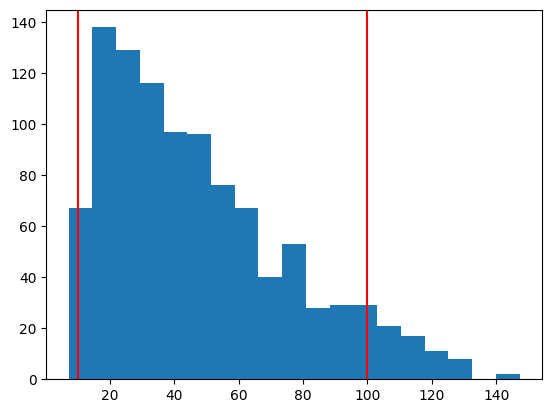

In [295]:
plt.hist(residual_zz/(2*pi) * 1e6, bins='auto');

plt.axvline(10,c='red')
plt.axvline(100,c='red')

In [107]:
ELdivEJ_array = xr.DataArray(EL_values/EJ_values)
EBdivEC_array = xr.DataArray(EJ_values/EC_values/calculate_EJdivEB(EL_values/EJ_values))
EC_array = xr.DataArray(EC_values)

In [171]:
fx = Fluxonium(
    EJ=2,
    EC=1.0,
    EL=0.2,
    dim=4,
    cutoff=64,
)
evals_one = fx.eigenvalues
evals_one[3] - evals_one[0]

np.float64(4.236497175817096)

In [305]:
fx = Fluxonium(
    EJ=2.8,
    EC=1.0,
    EL=0.4,
    dim=4,
    cutoff=64,
)
evals_one = fx.eigenvalues
evals_one[2] - evals_one[1]

np.float64(2.8951304746528823)

In [306]:
2.9/2

1.45

In [151]:

evals_one[2] - evals_one[1]

np.float64(3.254456161995549)

In [296]:
fx = Fluxonium(
    EJ=EJ_values,
    EC=EC_values,
    EL=EL_values,
    dim=8,
    cutoff=64,
)

In [297]:
evals = fx.eigenvalues
f10 = evals[..., 1] - evals[..., 0]
f21 = evals[..., 2] - evals[..., 1]
f30 = evals[..., 3] - evals[..., 0]

In [308]:
np.quantile(f21/f10, 0.01)

np.float64(1.9543076236956336)

In [307]:
np.quantile(f21, 0.01)/(2*pi)

np.float64(2.7315976057492475)

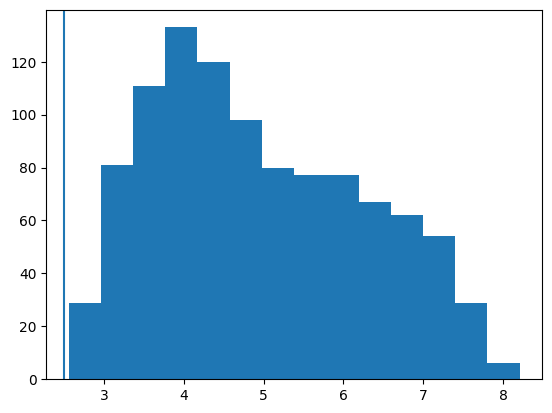

In [299]:
arr = f21

plt.hist(arr.ravel()/(2*pi), bins='auto');
# plt.xlim(0, 10)
plt.axvline(2.5)

In [187]:
np.quantile(f30, 0.03)/(2*pi)

np.float64(6.029418182014338)

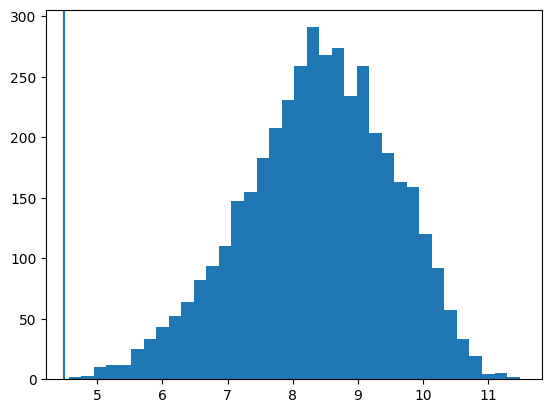

In [172]:
arr = f30

plt.hist(arr.ravel()/(2*pi), bins='auto');
# plt.xlim(0, 10)
plt.axvline(4.5)

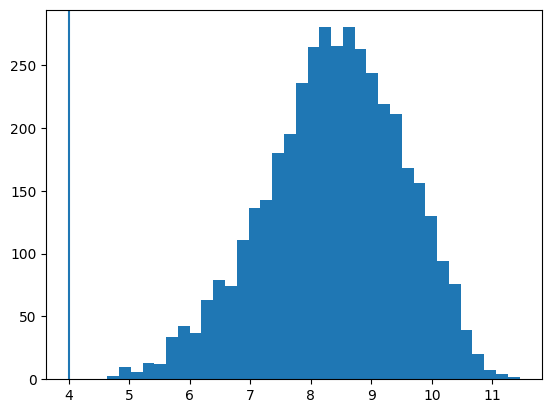

In [112]:

f10 = evals[..., 1] - evals[..., 0]
f30 = evals[..., 3] - evals[..., 0]
arr = f30

plt.hist(arr.ravel()/(2*pi), bins='auto');
# plt.xlim(0, 10)
plt.axvline(4)

In [76]:
ds = EC_array * dataset.interp(
    ELdivEJ=ELdivEJ_array,
    EBdivEC=EBdivEC_array,
)

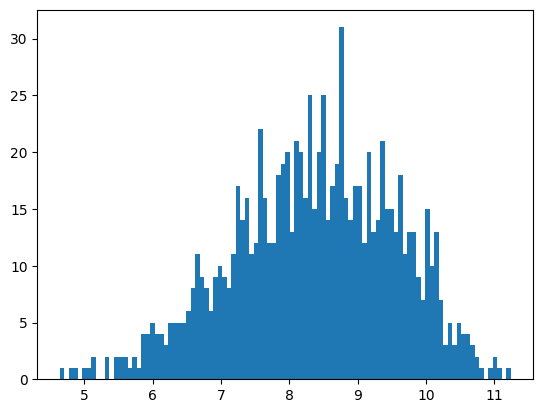

In [87]:
arr = ds.eigenenergy.sel(ket=3) - ds.eigenenergy.sel(ket=0)

plt.hist(arr.data.ravel()/(2*pi), bins=100);
# plt.xlim(0, 10)
# plt.axvline(5)

In [44]:
ds = dataset.sel(
    ELdivEJ=(
        (dataset.ELdivEJ >= 0.1)
        & (dataset.ELdivEJ <= 0.5)
    ),
    EBdivEC=(
        (dataset.EBdivEC >= 2)
        & (dataset.EBdivEC <= 8)
    ),
)

f10 = ds.eigenenergy.sel(ket=1) - ds.eigenenergy.sel(ket=0)

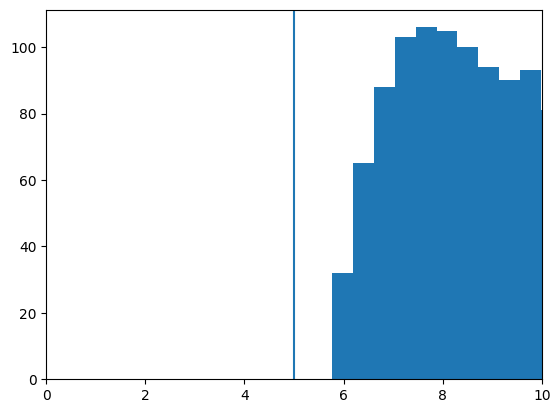

In [50]:

f10 = ds.eigenenergy.sel(ket=1) - ds.eigenenergy.sel(ket=0)
arr = (
    (ds.eigenenergy.sel(ket=3) - ds.eigenenergy.sel(ket=0))
    / f10
)

plt.hist(arr.data.ravel(), bins=100)
plt.xlim(0, 10)
plt.axvline(5)

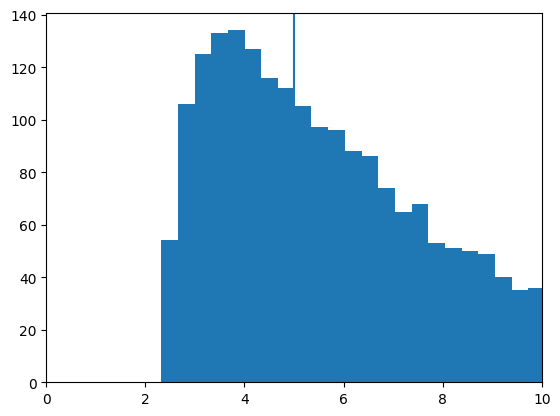

In [51]:
arr = (
    (ds.eigenenergy.sel(ket=2) - ds.eigenenergy.sel(ket=1))
    / f10
)

plt.hist(arr.data.ravel(), bins=100)
plt.xlim(0, 10)
plt.axvline(5)